<a href="https://colab.research.google.com/github/Eliezer-Carvalho/Adamastor-GPT/blob/main/tiny_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
#Autor: Eliezer Carvalho
#Parte da Documentação: Go Forward and Transform
#Github: https://github.com/Eliezer-Carvalho/Tiny-Transformer

# **Transformers**
<hr>

Os Transformers são uma arquitetura de Redes Neurais baseada no mecanismo <b> Attention</b>. <br>
Esta abordagem foi proposta em 2017 no artigo <b><i> ["Attention Is All You Need"](https://arxiv.org/pdf/1706.03762) </i></b> e desde então revolucionou o campo da Inteligência Artificial. <br>
Uma das maiores provas do impacto dos Transformers é o surgimento de modelos como: <br>

*    <b> [GPT](https://en.wikipedia.org/wiki/Generative_pre-trained_transformer) <i>(Generative Pre-trained Transformer)</i> </b>
*    <b> [BERT](https://en.wikipedia.org/wiki/BERT_(language_model)) <i>(Bidirectional Encoder Representations from Transformers)</i></b>.









O objetivo deste Google Colab é explorar de forma sucinta e prática a arquitetura dos Transformers. <br>
Ao longo do notebook, iremos percorrer os seus principais componentes construindo gradualmente a intuição por trás do modelo. <br>

No final, teremos a implementação de um <b>Transformer Decoder</b> simplificado, baseado numa <b>Single Head Attention</b>, permitindo compreender de forma clara os fundamentos desta arquitetura.


---



### <b> 1. Tokenização </b>
Como a arquitetura Transformer consiste em operações sobre números, deve haver primeiro um mapeamento de qualquer texto de entrada para representação numérica. <br>

A <b> Tokenização </b> divide o texto em pequenos fragmentos chamados tokens. <br>
Um token pode ser uma palavra inteira, parte de uma palavra ou até mesmo um sinal de pontuação. <br>

A forma como essa divisão é feita depende principalmente dos **Algoritmos de Tokenização**. <br>
Entre os mais comuns estão o **BPE (*Byte Pair Encoding*)**, **WordPiece** e o modelo **Unigram**, que frequentemente utilizam subpalavras (<i>subwords</i>) para representar o texto de forma mais eficiente. <br>

<b> Diferentes algoritmos produzem diferentes tokenizações, o que pode impactar o desempenho e a capacidade de generalização do modelo. </b> <br>

Por exemplo, o <i> tiktoken </i> que trata da Tokenização nos modelos GPT, baseia-se numa variante do BPE.


In [79]:
from tokenizers import Tokenizer #https://github.com/huggingface/tokenizers
from tokenizers.models import BPE #https://huggingface.co/docs/tokenizers/index
from tokenizers.trainers import BpeTrainer #https://huggingface.co/docs/tokenizers/index
import matplotlib.pyplot as plt #https://huggingface.co/docs/tokenizers/index

#### **Tokenizer**

In [80]:
Tokenizer = Tokenizer(BPE())
Trainer = BpeTrainer (
    vocab_size = 5000, #O tokenizer vai ter um vocabulário com 5000 tokens únicos.
)

Tokenizer.train (files = ["Os Lusiadas.txt"], trainer = Trainer)

In [81]:
with open ("Os Lusiadas.txt", "r", encoding = "utf-8") as f:
    dataset = f.read()

Tokenization = Tokenizer.encode (dataset)
print (f"Número de Tokens - {len(Tokenization.tokens)}")
print (Tokenization.tokens [:500])

print (f"Número de Ids - {len(Tokenization.ids)}")
print (Tokenization.ids [:500], "\n")

#Guardamos o Tokenizer para podermos usar em qualquer projeto!
Tokenizer.save ("GAMA")

Número de Tokens - 75017
['As ', 'armas ', 'e os ', 'Bar', 'ões ', 'assinal', 'ados ', 'Que ', 'da ', 'Ocid', 'ent', 'al ', 'praia ', 'Lusitan', 'a Por ', 'mares ', 'nunca ', 'de antes ', 'naveg', 'ados ', 'Pass', 'aram ', 'a', 'inda ', 'al', 'ém ', 'da ', 'T', 'apr', 'ob', 'ana, ', 'Em ', 'perig', 'os e ', 'guerras ', 'esforç', 'ados ', 'Mais ', 'do que ', 'promet', 'ia ', 'a força ', 'human', 'a, E ', 'entre ', 'gente ', 'remota ', 'edi', 'ficar', 'am ', 'Nov', 'o ', 'Rei', 'no, que ', 'tanto ', 'sublim', 'aram; ', 'E ', 'também ', 'as m', 'em', 'óri', 'as ', 'glori', 'osas ', 'Daqueles ', 'Reis ', 'que ', 'foram ', 'dilat', 'ando ', 'A ', 'F', 'é, ', 'o ', 'Impéri', 'o, e ', 'as terras ', 'vi', 'ci', 'osas ', 'De ', 'Áfri', 'ca e ', 'de ', 'Ásia ', 'and', 'aram ', 'dev', 'ast', 'ando, ', 'E ', 'aqueles ', 'que por ', 'obras ', 'valeros', 'as ', 'Se ', 'vão ', 'da ', 'lei ', 'da M', 'orte ', 'liber', 't', 'ando, ', 'Cant', 'ando ', 'espalh', 'arei ', 'por ', 'toda ', 'parte, ', 'Se '

#### **Codificador e Descodificador de um Tokenizer**


In [82]:
Tokenizer = Tokenizer.from_file ("GAMA")

teste = Tokenizer.encode ("Os Lusíadas são épicos")
print ("Codificador:")
print (teste.tokens)
print (teste.ids, "\n")

print ("Descodificador:")
print (Tokenizer.decode(teste.ids))


Codificador:
['Os ', 'Lus', 'í', 'adas ', 'são ', 'é', 'pi', 'cos']
[282, 429, 83, 790, 612, 79, 487, 538] 

Descodificador:
Os  Lus í adas  são  é pi cos


#### **Espaço Dimensional de um Tokenizer**


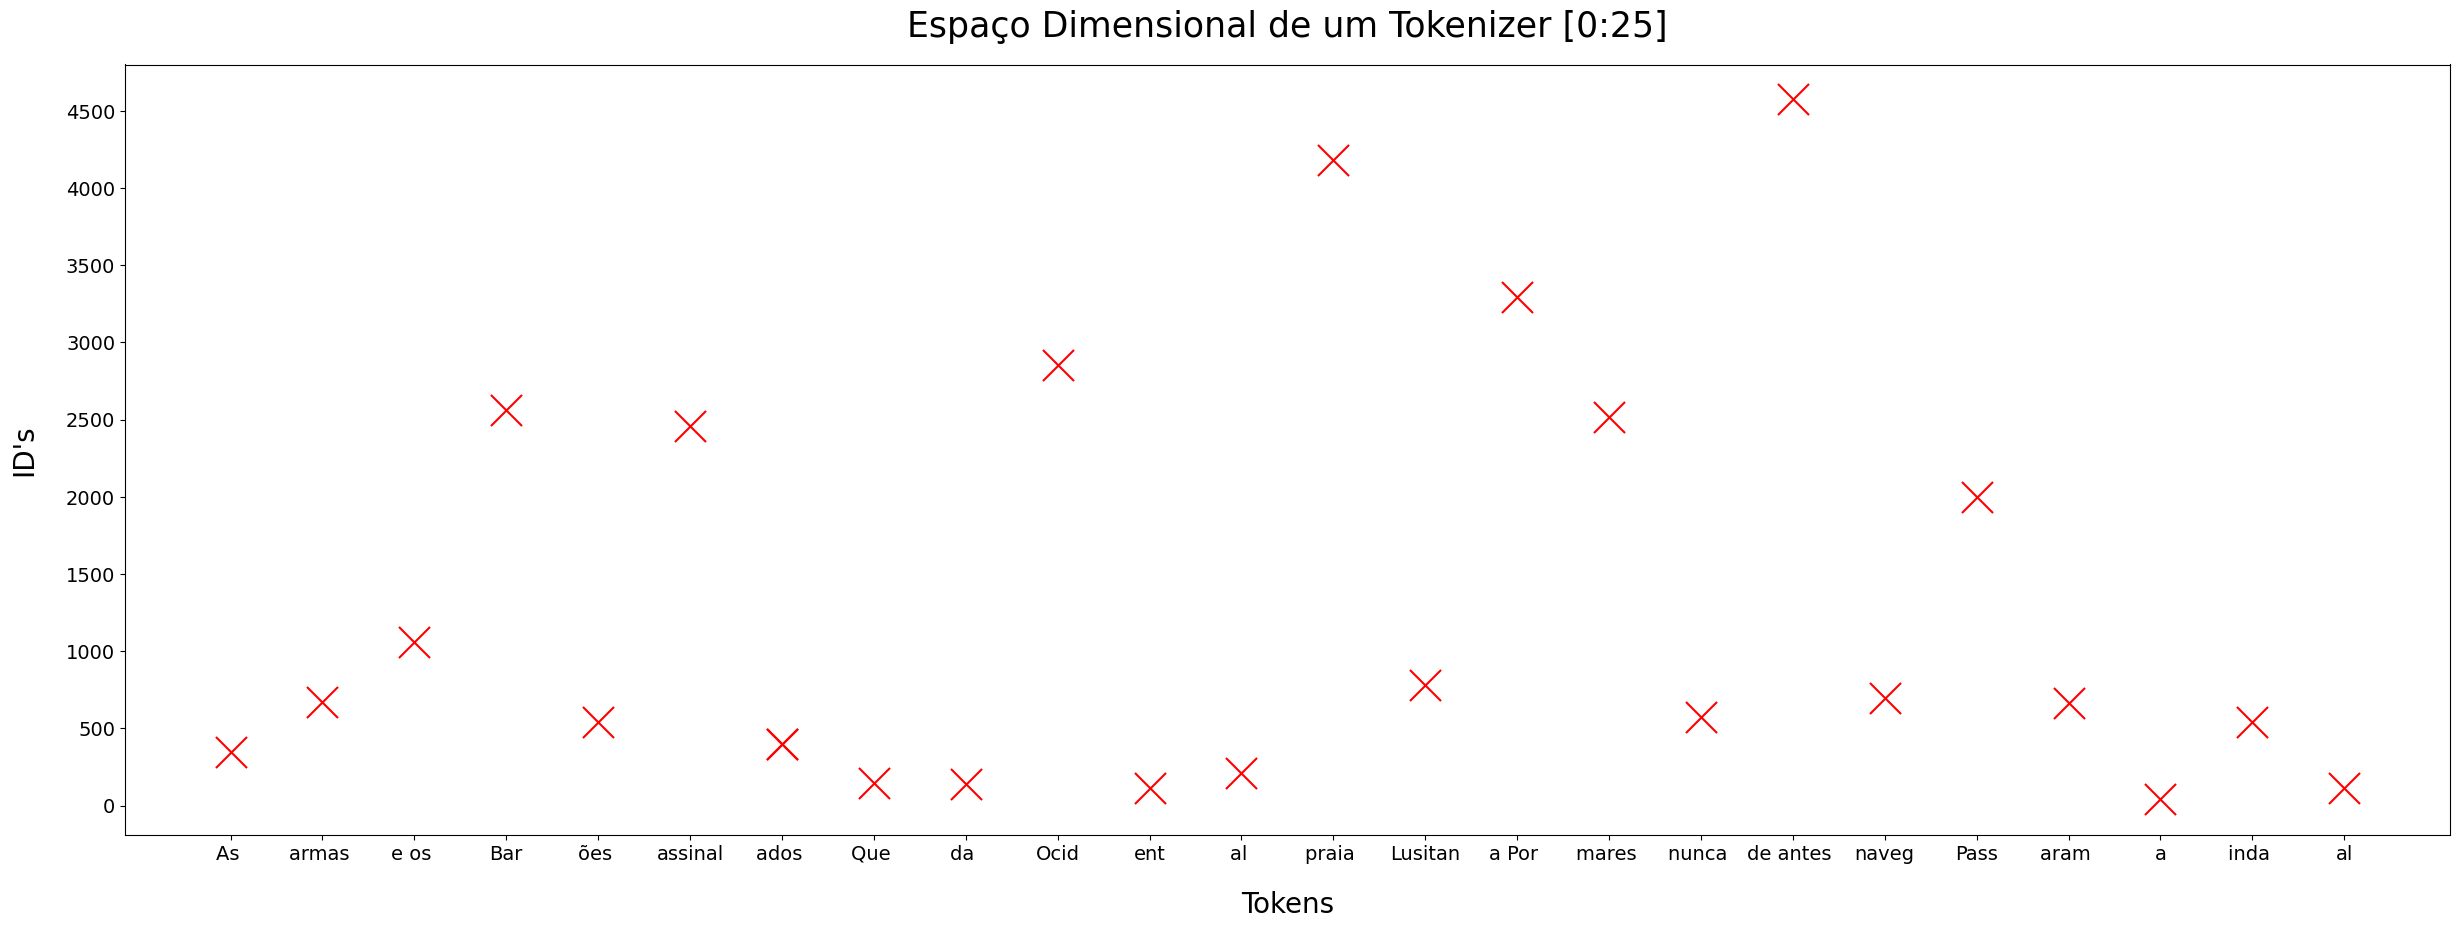

In [83]:
plt.figure (figsize = (30, 10))
plt.scatter (Tokenization.tokens [0:25], Tokenization.ids [0:25], marker = "x", color = 'red', s = 500)

plt.xticks (size = 14)
plt.xlabel ("Tokens", size = 20, labelpad = 20)
plt.yticks (list(range(0, 5000, 500)), size = 14)
plt.ylabel ("ID's", size = 20, labelpad = 20)

plt.title ("Espaço Dimensional de um Tokenizer [0:25]", size = 25, pad = 20)
plt.show()



###


---





### **2. Tensor Shape**

Após a Tokenização, o dataset já se encontra convertido para uma representação numérica. <br>
A organização dos dados de entrada é feita através da definição de dois parâmetros fundamentais: <br>


1.   **Batch Size** - número de sequências processadas em paralelo durante o treino.
2.   **Sequence Length** - número de tokens considerados em cada sequência.


Esta abordagem é necessária porque os Transformers não processam todo o texto de uma vez, mas sim em blocos de tamanho fixo. <br>
De forma análoga à leitura humana, não é possível analisar um texto completo simultaneamente, é necessário dividi-lo em partes para conseguir identificar padrões e relações.

<b> Assim, os dados são representados sob a forma de um tensor com dimensão (B, T). </b>



In [84]:
import torch #https://docs.pytorch.org/docs/stable/index.html
import torch.nn as nn #https://docs.pytorch.org/docs/stable/nn.html
import torch.nn.functional as F #https://docs.pytorch.org/docs/stable/nn.functional.html#torch-nn-functional

#### **Definição do Tensor e Dados de Treino vs Dados de Teste**

In [85]:
tensor = torch.tensor (Tokenization.ids, dtype = torch.long)
print (len(tensor))
print (tensor [:250])

#Divisão de Dados de Treino e Dados de Teste
n = int (0.9 * len(tensor))
dados_treino = tensor [:n] #90% dos dados
dados_teste = tensor [n:] #10% dos dados


75017
tensor([ 344,  672, 1062, 2563,  541, 2461,  398,  143,  138, 2854,  115,  208,
        4182,  783, 3295, 2515,  575, 4573,  694,  398, 1999,  662,   39,  543,
         114,  364,  138,   32, 1777,  229, 1896,  362,  708,  352, 2293,  733,
         398,  838, 1095, 2139,  248, 2930,  677, 1043,  878,  276, 3149,  510,
        1931,  167, 2354,   94,  205, 4432,  369,  982, 3321,  172,  642,  498,
         142,  315,  106, 1747, 1067, 3683, 1183,  108, 1550, 3652,  178,  187,
          19, 1603,   94, 3145, 1041, 1404,  150,  151, 1067,  191, 2399, 3729,
         110, 4469,  156,  662, 1339,  343,  318,  172, 1221, 2051, 1492, 2112,
         106,  322,  522,  138, 2603, 4646,  600, 2286,   57,  318, 2838,  178,
        1731, 2651,  186,  496, 1485,  322,   96,  369,  330, 3586,   94, 1376,
         225,  558,  243,   16, 3046,  109, 2035,  717,  507, 3991, 4367,   47,
         477,  344,  694, 1368,  935,  108, 1267,   98,  704, 1442, 2874,  110,
        3655, 4795,  696, 1335,  4

#### **Tensor (B, T)**

In [86]:
Batch_Size = 4
Sequence_Length = 8
torch.manual_seed (1000)

posição = torch.randint (0, len (dados_treino) - Sequence_Length, (Batch_Size, ))
x = torch.stack ([dados_treino [i:i + Sequence_Length] for i in posição])
y = torch.stack ([dados_treino [i + 1: i + Sequence_Length + 1] for i in posição])

print (x.shape) #(B, T)
print (x)
print (y.shape) #(B, T)
print (y)

#mais para a frente
sda = x

torch.Size([4, 8])
tensor([[ 814,  424,  412,  276,  535, 3946,  553, 1408],
        [1891,  514,  410,  324, 4195,  370, 1559,  103],
        [ 412,  276,  535, 3946,  553, 1408,   99,  125],
        [ 455,  958, 4759, 4166, 1521, 2537,  777,  628]])
torch.Size([4, 8])
tensor([[ 424,  412,  276,  535, 3946,  553, 1408,   99],
        [ 514,  410,  324, 4195,  370, 1559,  103, 3484],
        [ 276,  535, 3946,  553, 1408,   99,  125, 1062],
        [ 958, 4759, 4166, 1521, 2537,  777,  628,  793]])


###


---



### <b> 3. Embedding </b>

Word Embeddings são representações vetoriais de palavras.

Normalmente, cada token é mapeado para um <b> vetor de valores reais</b>, onde a sua posição no espaço vetorial reflete o seu significado. Palavras com significados semelhantes tendem a estar próximas nesse espaço, permitindo ao modelo capturar relações semânticas entre elas.

Neste ponto, introduz-se uma das variáveis fundamentais de uma arquitetura Transformer:


1.   <b> Embedding Dimension </b> - Define a dimensão dos vetores utilizados para representar cada token e é um dos principais fatores no número total de parâmetros do modelo.

Os Embeddings são parâmetros treináveis, ou seja, são ajustados durante o treino do modelo de forma a melhorar a representação dos tokens no espaço vetorial.

<b> Após a aplicação dos Embeddings passamos a ter um tensor com dimensão (B, T, C). </b>

In [87]:
Embedding_Dimension = 16

Embedding = nn.Embedding (Tokenizer.get_vocab_size(), Embedding_Dimension) #Porquê vocab_size ? Vocab_Size dá-nos o número dos tokens únicos que existem.
#Se usássemos por exemplo len(Tokenizer.tokens) não era correto porque estariamos a criar um vetor para tokens repetidos.
x_embedding = Embedding (x)
print (x_embedding.shape) #(B,T,C)
print (f"O Token {x[0,1]} agora é representado pelo vetor:")
print (x_embedding[0,1]) #Representação vetorial do primeiro token após embedding

torch.Size([4, 8, 16])
O Token 424 agora é representado pelo vetor:
tensor([ 1.6588, -0.5012, -1.5146, -0.3787,  0.6650,  0.6030,  1.3996,  1.6245,
         0.7058, -0.7769,  1.9255, -0.8397, -0.7665,  0.5943,  0.1082,  0.0352],
       grad_fn=<SelectBackward0>)


#### **Representação dos Tokens e dos seus respetivos Embeddings**
Cada token passa a ser representado por um vetor.

Esta tabela também é excelente para perceber o que <b> nn.Embedding </b> faz por trás.

In [88]:
import pandas as pd

dados = []

for i in range (8):
  dados.append ({
      "Token": sda[0,i],
      "Pós Embedding -> Sequence Length Posição 0": x_embedding[0,i].detach().cpu().numpy()
  })

df = pd.DataFrame (dados)
print(df.to_string()) #Melhor maneira de mostrar a tabela completa

          Token                                                                                                                                                          Pós Embedding -> Sequence Length Posição 0
0   tensor(814)     [0.5500665, 0.47044027, 0.5800977, -0.10416856, -0.9204427, 0.61324424, 1.169644, 1.7362368, -0.35076472, -0.5515117, 0.31320354, -0.3634649, 1.7392977, 0.37899518, -1.4683203, -0.0038908434]
1   tensor(424)           [1.6588235, -0.50120753, -1.5146004, -0.37867808, 0.6650362, 0.6029597, 1.3995639, 1.624547, 0.70583284, -0.776936, 1.92554, -0.8397268, -0.7665114, 0.59426033, 0.10816308, 0.035210826]
2   tensor(412)        [-0.46374524, 0.967462, -0.2886712, -0.6819441, -0.70813936, -0.39655825, -0.4460952, 0.5745262, -0.471401, 0.6732677, -0.55311453, 0.37344602, 0.5775724, -1.345826, -0.4589938, -2.629407]
3   tensor(276)    [1.5717665, -0.86543643, 1.9172549, 0.7501077, 0.3199631, -0.5103981, -0.13902253, 0.57268107, -0.54597944, -0.8266278, -0.7557086, 1

###


---


### **4. Positional Encoding**

<b>Positional Encoding</b> é uma técnica que adiciona informação sobre a posição de cada token na sequência.

Isto é necessário porque os Transformers, por si só, não processam os tokens de forma sequencial (como as RNNs) e, por isso, não têm noção da ordem das palavras.

Ao introduzir esta informação, o modelo consegue distinguir entre a posição relativa ou absoluta dos tokens, o que é essencial para compreender a estrutura de uma frase e o significado do texto.

A intuição é a seguinte:

* “Rei ama rainha” ≠ “Rainha ama rei” — <b>a ordem importa</b>!

No paper original são utilizados encodings fixos. <br>
No entanto, em muitas implementações modernas, são utilizados positional encodings treináveis, que permitem ao modelo aprender a melhor representação para cada posição durante o treino.

**Neste projeto foram utilizados encodings treináveis.**

In [89]:
Positional_Embedding = nn.Embedding (Sequence_Length, Embedding_Dimension) #Positinal Encoding não é nada mais do que um Embedding
Positional_Encoding = Positional_Embedding (torch.arange (Sequence_Length))
print (Positional_Encoding.shape)

torch.Size([8, 16])


###


---


### **5. Embedding + Positional Encoding**

Neste último passo, antes de introduzirmos o mecanismo <b> Attention</b>, é necessário combinar os Embeddings dos tokens com os Positional Encodings.

Esta combinação é feita através de uma soma elemento a elemento, permitindo que cada token transporte simultaneamente informação sobre o seu significado e a sua posição na sequência.

Este passo é fundamental, pois prepara a representação final que será utilizada pelo mecanismo <b> Attention<b>. <br>
Por essa razão, neste Notebook é apresentado como uma etapa separada e de especial importância no fluxo da arquitetura.

In [90]:
x = x_embedding + Positional_Encoding #Dados que vão entrar no modelo
print (x.shape)
print (x[:250])

torch.Size([4, 8, 16])
tensor([[[ 1.1952,  0.9325,  0.5382, -1.1921, -0.8127,  0.2045,  0.4940,
           1.6544, -0.3143, -1.7494,  0.4090, -0.3817,  2.6692, -0.4326,
          -1.7908, -0.4840],
         [ 2.5630, -1.1847, -2.6560, -0.5494,  0.5714, -0.6900,  2.9871,
           0.8046,  0.5712, -0.9030,  3.0544, -0.7942, -0.2159,  0.5006,
           1.3234,  0.3766],
         [-0.4494, -0.3055,  0.4546, -0.6268, -0.6252,  0.4393,  1.5622,
           0.3163, -1.5501, -0.4883, -0.9853, -0.1217,  1.1971, -0.6157,
          -2.2418, -1.7620],
         [ 1.8841, -2.2794,  0.5207,  2.4496,  0.3551,  0.9295, -0.3813,
          -2.1848,  0.0815, -0.1937, -0.2498,  3.7443,  0.1398,  0.8630,
          -0.0879, -1.5821],
         [ 0.2914,  1.7378, -0.2269,  1.6795, -2.5928, -0.7411, -0.8833,
           0.8195, -1.2617, -0.8396,  0.1171, -2.9306, -0.8224,  1.4836,
           1.9723,  0.4920],
         [-0.0465,  1.7980,  0.8809, -0.7181, -2.2598,  1.9035, -0.3339,
          -0.5872,  1.2454, -

##### **Dados Finais que vão entrar no modelo (Embedding + Positional Encoding)**

In [91]:
dados = []

for i in range (8):
  dados.append ({
      "Token": sda[0,i],
      "Dados Finais que vão entrar no modelo (Embedding + Positional Encoding) -> Sequence Length 0": x[0,i].detach().cpu().numpy()
  })

df = pd.DataFrame (dados)
print(df.to_string()) #Melhor maneira de mostrar a tabela completa

          Token                                                                                                      Dados Finais que vão entrar no modelo (Embedding + Positional Encoding) -> Sequence Length 0
0   tensor(814)  [1.1952037, 0.93253267, 0.53819036, -1.192095, -0.81268173, 0.20446005, 0.49404007, 1.6544439, -0.31434155, -1.7493846, 0.40895495, -0.38170955, 2.6691706, -0.4326012, -1.7907833, -0.48399884]
1   tensor(424)         [2.5629954, -1.1846509, -2.6560469, -0.5493501, 0.5714173, -0.69002444, 2.987084, 0.8046217, 0.5712165, -0.90298074, 3.0544133, -0.7941829, -0.21590018, 0.5005926, 1.3233969, 0.3765786]
2   tensor(412)   [-0.44939, -0.30550832, 0.4546067, -0.6267794, -0.62524486, 0.4392834, 1.5621653, 0.31625253, -1.5501406, -0.4882921, -0.9852809, -0.121680796, 1.1970873, -0.61571944, -2.2418222, -1.7620001]
3   tensor(276)   [1.8841305, -2.2793946, 0.52066517, 2.4496367, 0.35514995, 0.92948157, -0.38129997, -2.1848135, 0.08152443, -0.19370884, -0.24975997, 3.744338

###


---

### **6. [Attention](https://medium.com/@nitinmittapally/understanding-attention-in-transformers-a-visual-guide-df416bfe495a)**

<b> Attention </b> é um mecanismo que permite ao modelo focar-se em diferentes partes da sequência de entrada ao processar cada token.

De forma análoga à atenção humana, ao ler uma frase não analisamos cada palavra isoladamente, em vez disso, consideramos o contexto relevante para compreender o significado. <br>
Da mesma forma, o mecanismo <b> Attention </b> permite ao modelo atribuir diferentes níveis de importância aos vários tokens da sequência, capturando relações e dependências entre eles. <br>
Ao contrário das RNNs, este mecanismo permite acesso direto a todos os Tokens anteriores, facilitando a captura de dependências de longo alcance.

Este é o mecanismo central da arquitetura Transformer e pode ser aplicado de diferentes formas, destacando-se três variantes principais:

*   <b> Self-Attention </b> - cada token atende a todos os outros tokens da mesma sequência, permitindo capturar relações internas.
*   <b> Masked Self-Attention </b> - semelhante ao Self-Attention, mas com uma máscara que impede o modelo de “ver o futuro”, sendo essencial para tarefas de geração de texto.
*   <b> Cross-Attention </b> - permite relacionar duas sequências diferentes, onde uma sequência atende à outra


<b> Neste Notebook será utilizada a variante Masked Self-Attention, característica de modelos do tipo GPT. </b>

#### <b> Query, Key e Value (Q, K, V) </b>

<b> Attention </b> baseia-se em três representações vetoriais:

* <b> Query (Q) </b> - O que ando à procura ?
* <b> Key (K) </b> - O que ofereço ?
* <b> Value (V) </b> - O meu valor.

A Attention é calculada através da comparação entre <b> Queries </b> e <b> Keys</b>, permitindo determinar o grau de relevância entre tokens. <br>
Esses pesos são depois aplicados aos <b> Values </b> para produzir a saída final. <br>
<b> Vamos ver em código: </b>

In [92]:
B,T,C = x.shape #Batch, Sequence Length, Embedding_Dimension
#print (x.shape)
Head_Size = C = 16 #Head_Size representa a divisão do vetor #Se tiver um vetor com Emb_Dimension de valor 16, e tiver uma arquitetura Multi-Head Attention com 2 Heads, a minha Head_Size é 8. #Isto significa que por cada Head eu vou dar 8 valores do meu vetor de Embeddings

#C = Embedding_Dimension #Aplica uma Transformação Linear a partir dos Embeddings #Uma projeção desses Embeddings num espaço
Query = nn.Linear (C, Head_Size, bias = False)
Key = nn.Linear (C, Head_Size, bias = False)
Value = nn.Linear (C, Head_Size, bias = False)

#Aplico a projeção nos dados
Q = Query (x) #Y = X * Wq
K = Key (x) #Y = X * Wk
V = Value (x) #Y = X * Wv

print (x.shape)
print (Q.shape)
print (K.shape)
print (V.shape)

torch.Size([4, 8, 16])
torch.Size([4, 8, 16])
torch.Size([4, 8, 16])
torch.Size([4, 8, 16])


#### **Heatmap da Representação Vetorial do Embedding e dos respetivos Q, K e V**

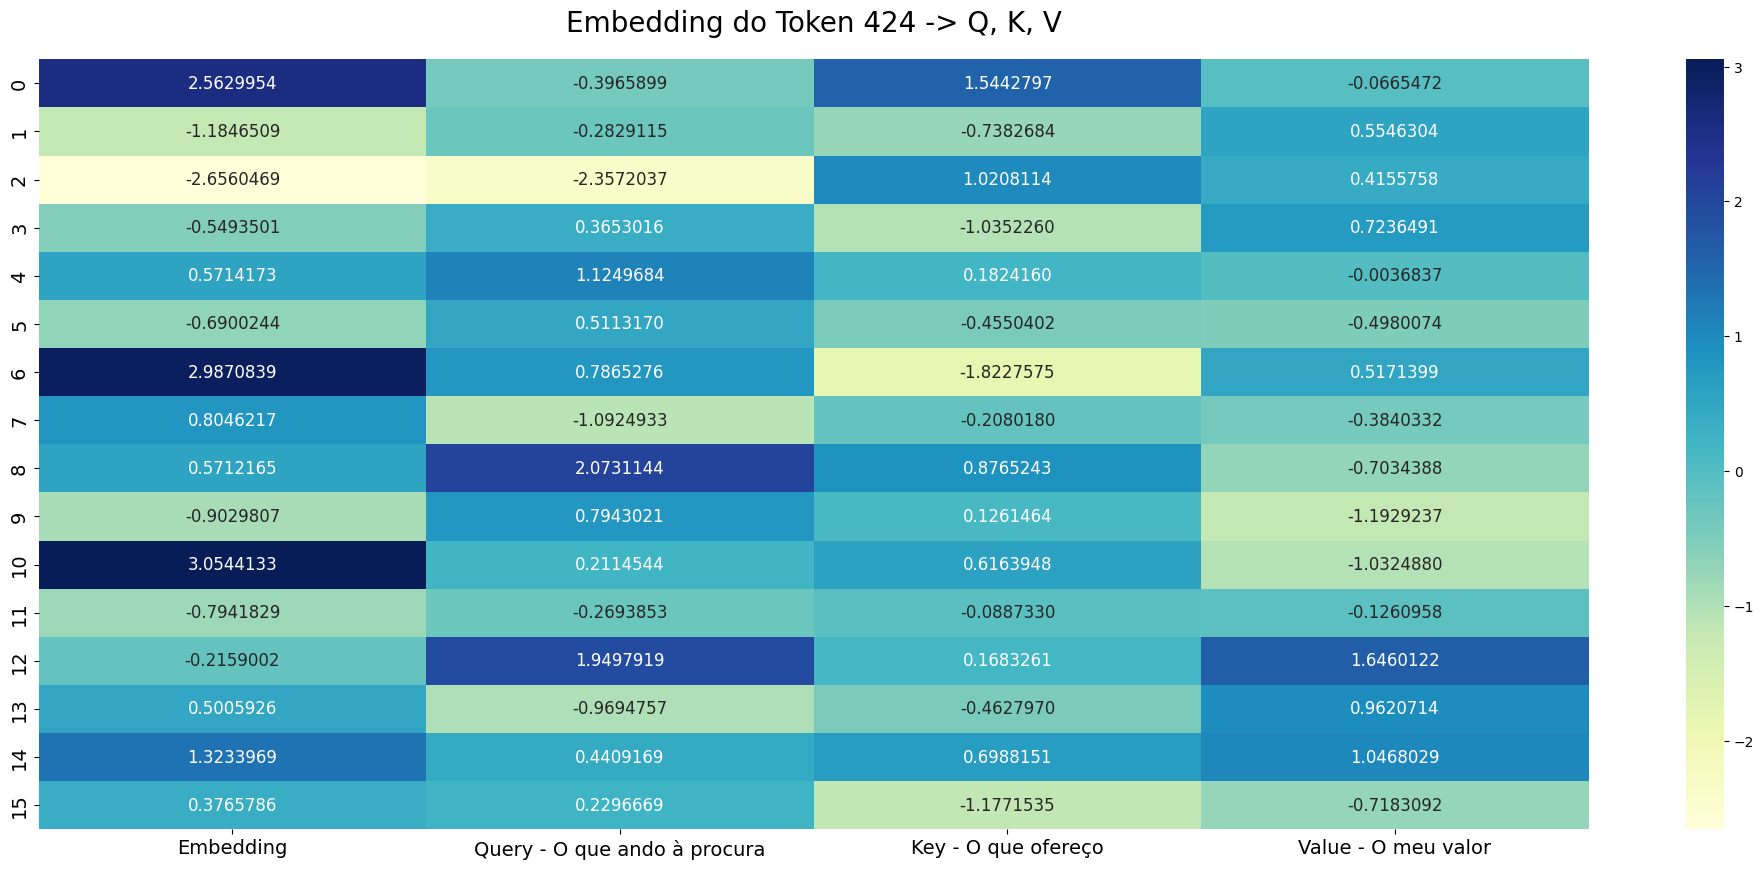

In [93]:
import seaborn as sns

df = pd.DataFrame({
    "Embedding": x [0,1].detach().numpy(), #x[0,1] vai selecionar um tensor da posição 1 da linha 0 do tensor
    "Query - O que ando à procura": Q [0,1].detach().numpy(),
    "Key - O que ofereço": K [0,1].detach().numpy(),
    "Value - O meu valor": V [0,1].detach().numpy(),
})

plt.figure (figsize = (25, 10))
sns.heatmap(df, cmap = "YlGnBu", annot = True, fmt = ".7f", annot_kws = {"size": 12})

plt.xticks (size = 14)
plt.yticks (size = 14)

plt.title("Embedding do Token 424 -> Q, K, V", size = 20, pad = 20)
plt.show()


#### **Representação do Espaço Dimensional do Embedding e dos respetivos Q, K e V**

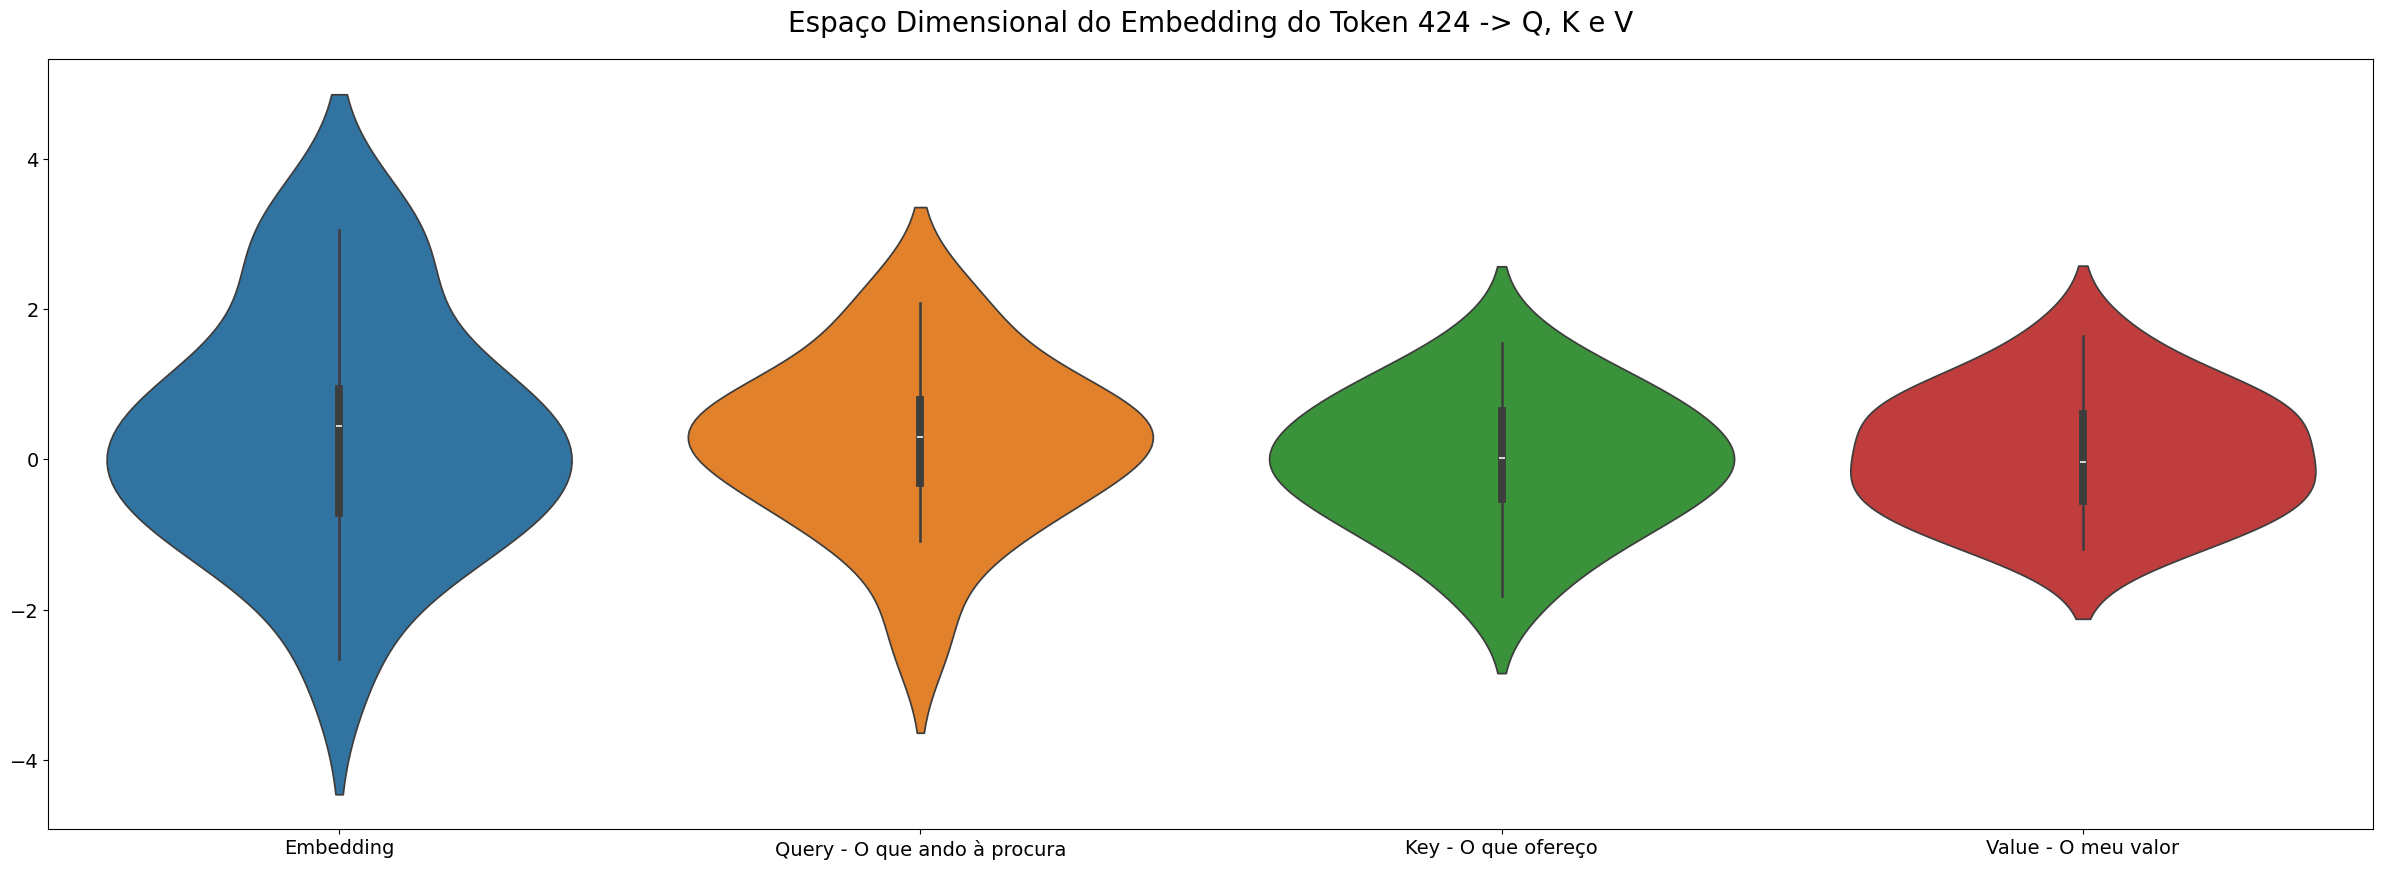

In [94]:
plt.figure (figsize = (30, 10))
sns.violinplot(df, cmap = "YlGnBu")

plt.xticks (size = 14)
plt.yticks (size = 14)

plt.title("Espaço Dimensional do Embedding do Token 424 -> Q, K e V", size = 20, pad = 20)
plt.show()

#### **Scaled Dot-Product Attention (Q @ K)**

**Scaled Dot-Product Attention** é o mecanismo central que permite aos tokens "interagir entre si" dentro de um Transformer.

Em vez de tratar cada posição isoladamente, o modelo passa a construir significado com base no contexto global.

É aqui que deixa de haver apenas transformações individuais (Q, K, V) e passa a haver comunicação entre tokens.

Um ponto importante é que este mecanismo é diferenciável e altamente <b> paralelizável </b>, o que o torna eficiente para treino em larga escala. <br>
Além disso, como todos os tokens podem atender a todos os outros simultaneamente, o modelo consegue capturar dependências de longo alcance — algo que era difícil em arquiteturas anteriores como RNNs.

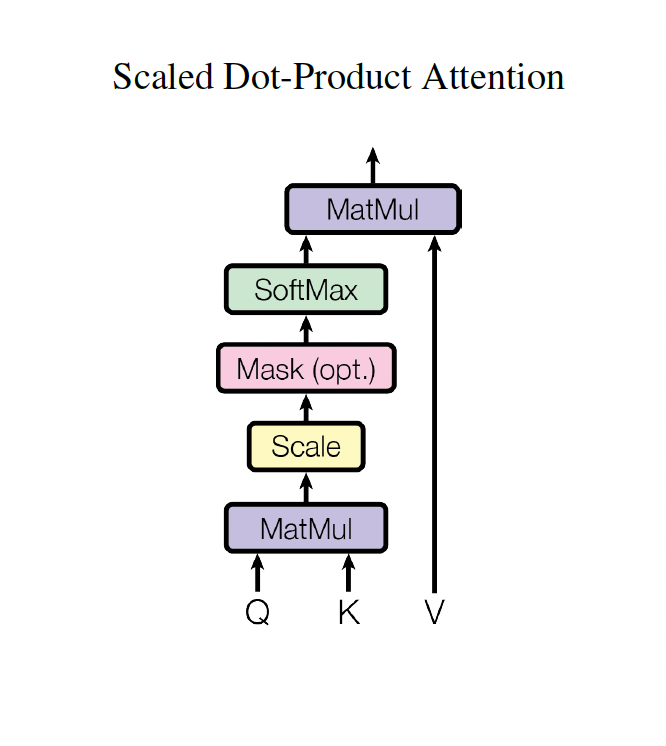

In [95]:
attention_scores = Q @ K.transpose (-2, -1) * (Head_Size ** -0.5) #(B, T, C) @ (B ,C ,T) --> (B, T, T) #Estamos a fazer com que os tokens falem entre si, troquem a sua informação
print (f"Após os Tokens falarem entre si -> \n {attention_scores.shape} \n") # (B, T, T) porque são apenas relações entre os tokens

tril = torch.tril (torch.ones(T, T)) #Cria uma máscara
print (f"Máscara -> \n {tril} \n")
attention_scores  = attention_scores.masked_fill (tril == 0, float ('-inf')) #Aplica a máscara na Atenção
print (f"Aplicação da Máscara na Atenção -> \n {attention_scores[0]} \n")

attention_scores = F.softmax (attention_scores, dim = -1) #Softmax para normalizar #A soma dos valores dá 1
print (f"Aplicação de Softmax para normalizar os valores -> \n {attention_scores[0]}\n")

output = attention_scores @ V #Resultado final mostra as relações entre todos os Tokens de uma Sequence length
print (f"Output -> \n{output.shape} \n{output[0]}")

Após os Tokens falarem entre si -> 
 torch.Size([4, 8, 8]) 

Máscara -> 
 tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]]) 

Aplicação da Máscara na Atenção -> 
 tensor([[ 0.2449,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf],
        [-0.6115, -0.3839,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf],
        [ 0.0633, -0.9008,  0.0593,    -inf,    -inf,    -inf,    -inf,    -inf],
        [-0.3152,  0.8464, -0.9414, -0.6068,    -inf,    -inf,    -inf,    -inf],
        [ 0.1245,  1.1530, -0.2367, -0.9572,  0.8240,    -inf,    -inf,    -inf],
        [ 0.3085,  0.3532, -0.0491, -0.5426,  0.5886,  0.0799,    -inf,    -inf],
        [-0.6338, -0.2811, -0.1884, -0.3434,  0.2244,  0.5

###


---